# Reentry and Spiral Waves

This tutorial introduces reentrant excitation patterns in cardiac tissue and demonstrates several classical approaches for their simulation using Finitewave.

We begin with the basic concepts of reentry and spiral waves, then demonstrate how to initialize both functional and anatomical reentries in two-dimensional tissue. Finally, we show and briefly discuss reentries in three-dimensional media.

## Table of Contents

1. [What is Reentry?](#1-what-is-reentry)
2. [How to Initialize Reentry](#2-how-to-initialize-reentry)  
   2.1 [Functional reentry: cross-field S1–S2 protocol](#21-functional-reentry-cross-field-s1s2-protocol)  
   2.2 [Anatomical reentry: rotation around an obstacle](#22-anatomical-reentry-rotation-around-an-obstacle)
3. [Reentries in 3D](#3-reentries-in-3d)

## 1. What is Reentry?

One of the main mechanisms associated with cardiac arrhythmias is reentry.

Reentry occurs when an excitation wave propagates along a closed path and repeatedly reactivates cardiac tissue instead of terminating after normal propagation. Such self-sustained activity disrupts coordinated excitation of the myocardium and may lead to tachyarrhythmias or fibrillation-like states.

Two major types of reentry are commonly distinguished:

- **Anatomical reentry**, where the rotating wave circulates around a fixed anatomical obstacle.
- **Functional reentry**, where rotation is maintained without a fixed obstacle and is instead sustained by tissue refractoriness and wavefront dynamics.

<p align="center">
  <img src="../images/types_of_reentry.png" width="800" alt="Types of reentry"/>
</p>

Examples of anatomical obstacles include scar tissue, fibrotic regions, or anatomical pathways surrounding cardiac valves.

In two-dimensional excitable-media models, functional reentry is often observed as a **spiral wave**: a rotating excitation pattern organized around a refractory core.

Unlike anatomical reentry, the center of a spiral wave is not a physical obstacle. Instead, the spiral core is dynamically maintained by refractory tissue and wavefront curvature.

Spiral waves are not unique to cardiac tissue and arise in many excitable media systems, including the Belousov-Zhabotinsky reaction, chemical oscillators, and some biological systems.

For a detailed review of cardiac reentry mechanisms and spiral-wave theory, see:

> P. Comtois and A. Vinet,  
> *Bridging the gap between the leading circle and spiral wave concepts of cardiac reentry*,  
> Europace, 2005.

## 2. How to Initialize Reentry

### 2.1 Functional Reentry: Cross-Field S1–S2 Protocol

One of the classical approaches for initiating functional reentry in excitable media is the cross-field S1-S2 protocol.

In this example, the first stimulus (**S1**) creates a planar excitation wave propagating through the tissue. After a short delay, a second stimulus (**S2**) is applied only to part of the domain and in a perpendicular direction.

At the moment of the second stimulation, part of the tissue is still refractory due to the previous excitation wave. As a result, the S2 wavefront cannot propagate uniformly across the entire domain. Instead, the wavefront becomes partially blocked, bends around the refractory region, and starts to rotate, forming a spiral wave.

This type of reentry is called **functional reentry**, since the rotating excitation pattern is maintained by the electrophysiological state of the tissue rather than by a fixed anatomical obstacle.

Running AlievPanfilov: 100%|█████████▉| 14900/14901 [00:02<00:00, 5767.58it/s]


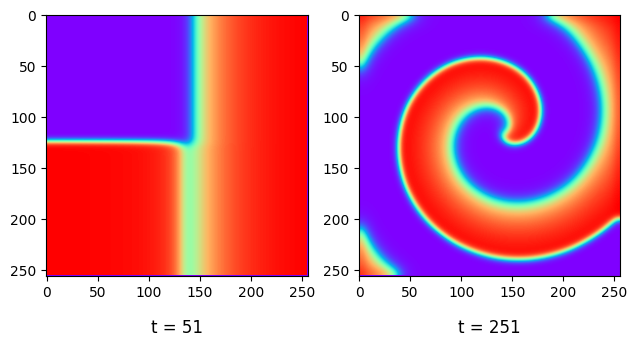

In [12]:
import matplotlib.pyplot as plt
import finitewave as fw

n = 256
tissue = fw.CardiacTissue([n, n])

stim_sequence = fw.StimSequence()

# S1: planar wave from the upper border
stim_sequence.add_stim(
    fw.StimVoltageCoord(
        time=0,
        volt_value=1,
        x1=0, x2=n,
        y1=0, y2=5,
    )
)

# S2: transverse stimulus applied to only half of the tissue
stim_sequence.add_stim(
    fw.StimVoltageCoord(
        time=50,
        volt_value=1,
        x1=n // 2, x2=n,
        y1=0, y2=n,
    )
)

model = fw.AlievPanfilov()
model.dt = 0.01
model.dr = 0.3
model.t_max = 51

model.cardiac_tissue = tissue
model.stim_sequence = stim_sequence

model.run()

u_after_s2 = model.u.copy()

model.t_max = 200
model.run(initialize=False)

u_final = model.u.copy()

fig, axs = plt.subplots(ncols=2)
plt.rcParams["axes.titley"] = -0.25
axs[0].imshow(u_after_s2, cmap='rainbow')
axs[0].set_title("t = 51")
axs[1].imshow(u_final, cmap='rainbow')
axs[1].set_title("t = 251")
plt.tight_layout()
plt.show()

### 2.2 Anatomical Reentry: Rotation Around an Obstacle

In the second example, we initiate anatomical reentry around a fixed non-conductive obstacle.

Unlike functional reentry, anatomical reentry does not require a dynamically maintained spiral core. Instead, the excitation wave rotates around a fixed anatomical or structural obstacle. In simulations, such an obstacle can be represented as a non-conductive region within the tissue.

To initiate a stable rotating wave, we stimulate only one side of the domain while temporarily keeping the opposite side refractory. This creates a unidirectional propagation pathway around the obstacle. After the refractory region recovers, the excitation wave can continue circulating around the obstacle and form a sustained reentrant circuit.

This mechanism resembles classical anatomical reentry observed in cardiac tissue, where excitation waves circulate around scar tissue, fibrotic regions, or other non-conductive anatomical structures.

Running AlievPanfilov:   0%|          | 0/2000 [00:00<?, ?it/s]

Running AlievPanfilov: 100%|██████████| 16000/16000 [00:02<00:00, 6119.85it/s]


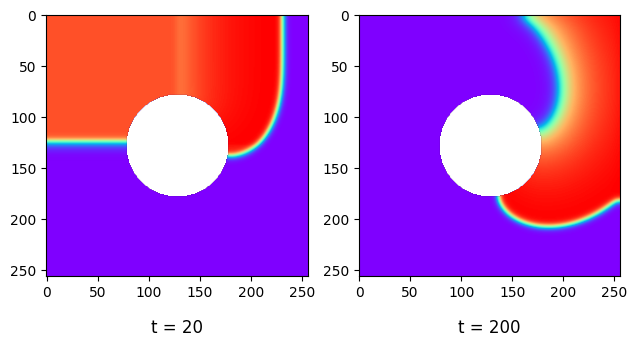

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

n = 256
tissue = fw.CardiacTissue([n, n])

# Create a circular non-conductive obstacle in the center
x, y = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")

cx, cy = n // 2, n // 2
radius = 50

obstacle = (x - cx) ** 2 + (y - cy) ** 2 < radius ** 2

tissue.mesh[obstacle] = 0 # non-conductive


stim_sequence = fw.StimSequence()

# Stimulate only the left half of the upper border
stim_sequence.add_stim(
    fw.StimVoltageCoord(
        time=0,
        volt_value=1,
        x1=0, x2=n // 2,
        y1=0, y2=n // 2,
    )
)

model = fw.AlievPanfilov()
model.dt = 0.01
model.dr = 0.3
model.t_max = 20

model.cardiac_tissue = tissue
model.stim_sequence = stim_sequence

# Temporarily keep the right half refractory using 'v' variable
model.init_v = np.zeros_like(tissue.mesh, dtype=np.float64)
model.init_v[n // 2:, :] = 1.0

model.run()

u_before_release = model.u.copy()

model.t_max = 180
model.run(initialize=False)

u_final = model.u.copy()

u_anat_wave = u_final.copy()

fig, axs = plt.subplots(ncols=2)
plt.rcParams["axes.titley"] = -0.25
obstacle_overlay = np.ma.masked_where(~obstacle, obstacle)
axs[0].imshow(u_before_release, cmap='rainbow')
axs[0].imshow(obstacle_overlay, cmap='gray', alpha=1.0, vmin=0, vmax=1)
axs[0].set_title("t = 20")
axs[1].imshow(u_final, cmap='rainbow')
axs[1].imshow(obstacle_overlay, cmap='gray', alpha=1.0, vmin=0, vmax=1)
axs[1].set_title("t = 200")
plt.tight_layout()
plt.show()

In the S1–S2 example, the spiral core is functional and dynamically maintained.

In the anatomical reentry example, the rotating wave is anchored by a fixed non-conductive obstacle.

In this example, the result is not a single stable reentrant circuit. Instead, repeated pacing in a highly heterogeneous medium produces wavefront fragmentation and several interacting excitation sources.

After the last external stimulus, the simulation is continued without further stimulation. If excitation persists for a long time after pacing has stopped, this indicates self-sustained activity maintained by the tissue dynamics rather than by the external pacing sequence.

## 3. Reentry in 3D

The same basic principles used to initiate reentry in two-dimensional tissue can also be applied in three-dimensional tissue.

In 2D, functional reentry is usually observed as a **spiral wave** rotating around a spiral core. In 3D, this pattern extends into a **scroll wave**. Instead of a single rotation center on a plane, a scroll wave rotates around a three-dimensional organizing structure called a **filament**.

In this example, we use a 3D slab and apply a cross-field S1-S2 protocol similar to the 2D case. The first stimulus creates a propagating wavefront, while the second stimulus is applied to only part of the slab. This creates a broken wavefront that can curl and develop into a three-dimensional reentrant pattern.

The visualization below shows only the excited part of the tissue, defined by a simple threshold on the membrane potential variable `u`.

Running AlievPanfilov: 100%|█████████▉| 9999/10000 [00:53<00:00, 185.61it/s]


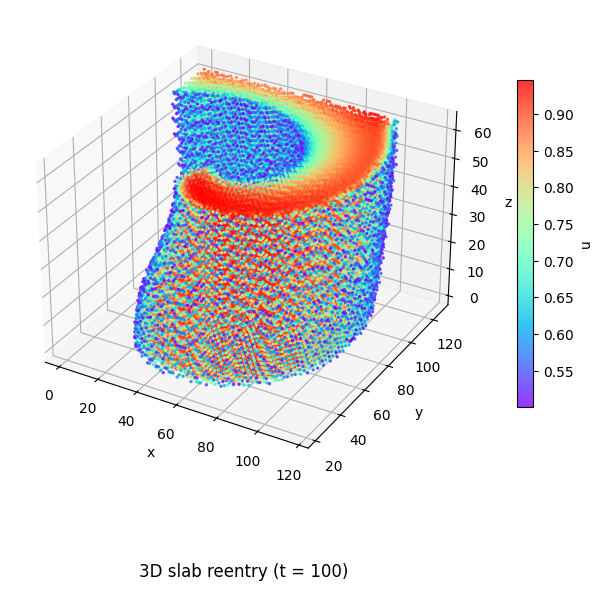

In [ ]:
import matplotlib.pyplot as plt
import finitewave as fw

n = 128
k = 64
tissue = fw.CardiacTissue([n, n, k])

stim_sequence = fw.StimSequence()

# S1: planar wave from the upper border
stim_sequence.add_stim(
    fw.StimVoltageCoord(
        time=0,
        volt_value=1,
        x1=0, x2=n,
        y1=0, y2=5,
        z1=0, z2=5
    )
)

# S2: transverse stimulus applied to only half of the slab
stim_sequence.add_stim(
    fw.StimVoltageCoord(
        time=40,
        volt_value=1,
        x1=n // 2, x2=n,
        y1=0, y2=n,
        z1=0, z2=k
    )
)

model = fw.AlievPanfilov()
model.dt = 0.01
model.dr = 0.3
model.t_max = 100

model.cardiac_tissue = tissue
model.stim_sequence = stim_sequence

model.run()

u_3d = model.u
active = u_3d > 0.5  # excitation threshold

x, y, z = active.nonzero()

# Downsample for faster 3D rendering
step = max(1, len(x) // 80000)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

pts = ax.scatter(
    x[::step], y[::step], z[::step],
    c=u_3d[x[::step], y[::step], z[::step]],
    cmap="rainbow",
    s=2,
    alpha=0.8
)

ax.set_title("3D slab reentry (t = 100)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(pts, ax=ax, shrink=0.7, label="u")
plt.tight_layout()
plt.show()

The resulting structure is the three-dimensional analogue of a spiral wave. In a full 3D simulation, the dynamics may include scroll-wave rotation, filament motion, filament bending, and interactions with tissue boundaries.

This example is intentionally simple: it demonstrates that the same reentry initiation logic used in 2D can be extended to 3D, while introducing new geometric features that do not exist in planar tissue.